# Assignment: Video Quality Inference

To this point in the class, you have learned various techniques for leading and analyzing packet captures of various types, generating features from those packet captures, and training and evaluating models using those features.

In this assignment, you will put all of this together, using a network traffic trace to train a model to automatically infer video quality of experience from a labeled traffic trace.

## Part 1: Warmup

The first part of this assignment builds directly on the hands-on activities but extends them slightly.

### Extract Features from the Network Traffic

Load the `netflix.pcap` file, which is a packet trace that includes network traffic. 


In [1]:
from netml.pparser.parser import PCAP

In [2]:
pcap = PCAP("../notebooks/data/netflix.pcap", flow_ptks_thres=2)

In [3]:
pcap.pcap2pandas()

In [4]:
netflix_dat = pcap.df

In [5]:
netflix_dat.head()

,datetime,dns_query,dns_resp,ip_dst,ip_dst_int,ip_src,ip_src_int,is_dns,length,mac_dst,mac_dst_int,mac_src,mac_src_int,port_dst,port_src,protocol,time,time_normed
0,2018-02-11 15:10:00,"(fonts.gstatic.com.,)",None,128.93.77.234,2.153598e+09,192.168.43.72,3.232247e+09,True,77,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,53.0,55697.0,UDP,1518358200.534682,0.000000
1,2018-02-11 15:10:00,"(fonts.gstatic.com.,)",None,128.93.77.234,2.153598e+09,192.168.43.72,3.232247e+09,True,77,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,53.0,59884.0,UDP,1518358200.534832,0.000150
2,2018-02-11 15:10:00,"(googleads.g.doubleclick.net.,)",None,128.93.77.234,2.153598e+09,192.168.43.72,3.232247e+09,True,87,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,53.0,61223.0,UDP,1518358200.539408,0.004726
3,2018-02-11 15:10:00,"(googleads.g.doubleclick.net.,)",None,128.93.77.234,2.153598e+09,192.168.43.72,3.232247e+09,True,87,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,53.0,58785.0,UDP,1518358200.541204,0.006522
4,2018-02-11 15:10:00,"(ytimg.l.google.com.,)",None,128.93.77.234,2.153598e+09,192.168.43.72,3.232247e+09,True,78,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,53.0,51938.0,UDP,1518358200.545785,0.011103


### Identifying the Service Type

Use the DNS traffic to filter the packet trace for Netflix traffic.

In [6]:
dns_dat = netflix_dat[(netflix_dat["is_dns"] == True) & (netflix_dat["dns_resp"].notna())]

In [7]:
dns_dat = dns_dat[dns_dat["dns_query"].str[0].str.contains("netflix|nflx")]

In [8]:
dns_dat

,datetime,dns_query,dns_resp,ip_dst,ip_dst_int,ip_src,ip_src_int,is_dns,length,mac_dst,mac_dst_int,mac_src,mac_src_int,port_dst,port_src,protocol,time,time_normed
101,2018-02-11 15:10:02,"(ipv4-c001-cdg001-ix.1.oca.nflxvideo.net.,)","(198.38.120.130,)",192.168.43.72,3.232247e+09,128.93.77.234,2.153598e+09,True,109,e4:ce:8f:01:4c:54,251575813622868,a0:ce:c8:0d:2b:a7,176809980013479,48058.0,53.0,UDP,1518358202.902769,2.368087
102,2018-02-11 15:10:02,"(www.eu-west-1.prodaa.netflix.com.,)","(52.19.39.146,)",192.168.43.72,3.232247e+09,128.93.77.234,2.153598e+09,True,102,e4:ce:8f:01:4c:54,251575813622868,a0:ce:c8:0d:2b:a7,176809980013479,43209.0,53.0,UDP,1518358202.902776,2.368094
103,2018-02-11 15:10:02,"(customerevents.eu-west-1.prodaa.netflix.com.,)","(52.210.19.176,)",192.168.43.72,3.232247e+09,128.93.77.234,2.153598e+09,True,113,e4:ce:8f:01:4c:54,251575813622868,a0:ce:c8:0d:2b:a7,176809980013479,4046.0,53.0,UDP,1518358202.902810,2.368128
104,2018-02-11 15:10:02,"(ipv4-c024-cdg001-ix.1.oca.nflxvideo.net.,)","(198.38.120.153,)",192.168.43.72,3.232247e+09,128.93.77.234,2.153598e+09,True,109,e4:ce:8f:01:4c:54,251575813622868,a0:ce:c8:0d:2b:a7,176809980013479,50901.0,53.0,UDP,1518358202.902831,2.368149
219,2018-02-11 15:10:03,"(occ-0-56-55.1.nflxso.net.,)","(198.38.120.137,)",192.168.43.72,3.232247e+09,128.93.77.234,2.153598e+09,True,94,e4:ce:8f:01:4c:54,251575813622868,a0:ce:c8:0d:2b:a7,176809980013479,57216.0,53.0,UDP,1518358203.642910,3.108228
228,2018-02-11 15:10:03,"(ipv4-c072-cdg001-ix.1.oca.nflxvideo.net.,)","(198.38.120.167,)",192.168.43.72,3.232247e+09,128.93.77.234,2.153598e+09,True,109,e4:ce:8f:01:4c:54,251575813622868,a0:ce:c8:0d:2b:a7,176809980013479,15562.0,53.0,UDP,1518358203.670254,3.135572
1019,2018-02-11 15:10:12,"(push.prod.eu-west-1.prodaa.netflix.com.,)","(34.252.77.54,)",192.168.43.72,3.232247e+09,128.93.77.234,2.153598e+09,True,108,e4:ce:8f:01:4c:54,251575813622868,a0:ce:c8:0d:2b:a7,176809980013479,36897.0,53.0,UDP,1518358212.323453,11.788771
1566,2018-02-11 15:10:20,"(ipv4-c005-cdg001-ix.1.oca.nflxvideo.net.,)","(198.38.120.134,)",192.168.43.72,3.232247e+09,128.93.77.234,2.153598e+09,True,109,e4:ce:8f:01:4c:54,251575813622868,a0:ce:c8:0d:2b:a7,176809980013479,22331.0,53.0,UDP,1518358220.775688,20.241006
1598,2018-02-11 15:10:20,"(ipv4-c069-cdg001-ix.1.oca.nflxvideo.net.,)","(198.38.120.164,)",192.168.43.72,3.232247e+09,128.93.77.234,2.153598e+09,True,109,e4:ce:8f:01:4c:54,251575813622868,a0:ce:c8:0d:2b:a7,176809980013479,9948.0,53.0,UDP,1518358220.809416,20.274734
1600,2018-02-11 15:10:20,"(ipv4-c071-cdg001-ix.1.oca.nflxvideo.net.,)","(198.38.120.166,)",192.168.43.72,3.232247e+09,128.93.77.234,2.153598e+09,True,109,e4:ce:8f:01:4c:54,251575813622868,a0:ce:c8:0d:2b:a7,176809980013479,1971.0,53.0,UDP,1518358220.820322,20.285640


In [9]:
netflix_ips = dns_dat["dns_resp"].to_list()

In [10]:
netflix_ips = [val[0] for val in netflix_ips]

### Generate Statistics

Generate statistics and features for the Netflix traffic flows. Use the `netml` library or any other technique that you choose to generate a set of features that you think would be good features for your model. 

In [11]:
pcap.pcap2flows()

In [12]:
filtered_flows = []

for flow in pcap.flows:
    if flow[0][0] in netflix_ips or flow[0][1] in netflix_ips:
        filtered_flows.append(flow)

In [13]:
pcap.flows = filtered_flows

In [14]:
pcap.flow2features('SAMP_SIZE', fft=False, header=False)
sampsize_feature = pcap.features

**Write a brief justification for the features that you have chosen.**

I chose samp size for the feature because it will tell me how many bytes arrived per interval. Theoretically, more bytes mean the video quality is higher and less bytes mean the video quality is lower, so I think that this will be a good feature to train on.

### Inferring Segment downloads

In addition to the features that you could generate using the `netml` library or similar, add to your feature vector a "segment downloads rate" feature, which indicates the number of video segments downloaded for a given time window.

Note: If you are using the `netml` library, generating features with `SAMP` style options may be useful, as this option gives you time windows, and you can then simply add the segment download rate to that existing dataframe.

In [15]:
import pandas as pd

In [16]:
samp = pd.DataFrame(pcap.features)

In [17]:
'''
I don't really understand this, so I'm treating it as # of segments per second per flow. Since packet size is capped at 200, I assume all packets
at or above 200 is a possible request and divided it over seconds.

'''

rates = []
CLIENT = "192.168.43.72"

for flow, packet in pcap.flows:
    # figure out total time
    packet_times = []
    n = 0
    
    for p in packet:
        packet_times.append(p.time)

        if len(p) >= 200 and flow[0] == CLIENT:
            n+=1
    time = packet_times[-1] - packet_times[0]
    if time == 0:
        rates.append(0)
    else:
        rates.append(n/time)

samp["seg_download_rate"] = rates

In [18]:
samp

,0,1,2,3,4,5,6,7,8,9,...,926,927,928,929,930,931,932,933,934,seg_download_rate
0,1064.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.06925122870723814534960340168
1,998.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.06923834017696627365830809884
2,1064.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.06926445306709924626422172383
3,9343.0,3384.0,0.0,7994.0,0.0,0.0,0.0,4116.0,790.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.6337568680069745807538078471
4,3130.0,0.0,0.0,54.0,198.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1470242158373228911210699375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,2850.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0E+6
106,7615.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0E+6
107,9650.0,132.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0E+6
108,11295.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.9547997784864513911432772548


## Part 2: Video Quality Inference

You will now load the complete video dataset from a previous study to train and test models based on these features to automatically infer the quality of a streaming video flow.

For this part of the assignment, you will need two pickle files. They are hosted in the course data repository on GitHub, [noise-courses/data](https://github.com/noise-courses/data), in the `video-qoe/` directory. Download them by running the code below:

```
!wget https://raw.githubusercontent.com/noise-courses/data/main/video-qoe/netflix_session.pkl
!wget https://raw.githubusercontent.com/noise-courses/data/main/video-qoe/video_dataset.pkl.xz
!xz -d video_dataset.pkl.xz
```

The dataset is stored xz-compressed in the repository (61 MB compressed, about 265 MB uncompressed), so the last line decompresses it. If `xz` is not available on your system, you can decompress it in Python instead:

```python
import lzma, shutil
with lzma.open('video_dataset.pkl.xz') as f_in, open('video_dataset.pkl', 'wb') as f_out:
    shutil.copyfileobj(f_in, f_out)
```

A smaller Netflix-only dataset (`netflix_dataset.pkl.xz`, 52,279 samples with 251 features) is available in the same directory and may be used instead of the multi-service `video_dataset.pkl` (204,713 samples with 170 features).

**Backup (Google Drive):** If GitHub is unavailable, the Netflix-only dataset is also mirrored on Google Drive:

```
!gdown 'https://drive.google.com/uc?id=1iI1tos08p9FJBI-ADR9b_iFObWRwXANX' -O netflix_dataset.pkl
```

Note: the Google Drive links that previously appeared here (file IDs `1N-Cf4dJ3fpak_AWgO05Fopq_XPYLVqdS` and `1PHvEID7My6VZXZveCpQYy3lMo9RvMNTI`) no longer work.

### Load the File

Load the video dataset pickle file.

In [19]:
df = pd.read_pickle("video_dataset.pkl")

### Clean the File

1. The dataset contains video resolutions that are not valid. Remove entries in the dataset that do not contain a valid video resolution. Valid resolutions are 240, 360, 480, 720, 1080.

In [20]:
valid_res = [240, 360, 480, 720, 1080]

In [21]:
df = df[df["resolution"].isin(valid_res)]

2. The file also contains columns that are unnecessary (in fact, unhelpful!) for performing predictions. Identify those columns, and remove them.

In [22]:
cols = ["index", "home_id", "session_id", "video_id", "absolute_timestamp", "service"]

In [23]:
df = df.drop(columns=cols)

**Briefly explain why you removed those columns.**

index, home_id, session_id, and video_id are all identifiers that won't help in the predictions and will just add noise. Meanwhile, absolute_timestamp is not that helpful when we already have relative_timestamp in the dataset. Service is not that helpful since we are only predicting based on video quality and service won't matter too much here since we are also testing on netflix only.

### Prepare Your Data

Prepare your data matrix, determine your features and labels, and perform a train-test split on your data.

In [24]:
X = df.drop(columns=["resolution"])
y = df["resolution"]

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Train and Tune Your Model

1. Select a model of your choice.
2. Train the model using your training data.

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [28]:
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)

In [29]:
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    class_weight="balanced",
    max_features=0.2,
    random_state=42,
)

clf.fit(X_train_norm, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=25, max_features=0.2,
                       n_estimators=300, random_state=42)

### Tune Your Model

Perform hyperparameter tuning to find optimal parameters for your model.

In [30]:
'''
Initial Weights: 

clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
)

accuracy: 0.8933846499887537
f1: 0.8936482808694398
Confusion:
[[ 8271   377   340    40    10]
 [  281  5562   429   101     2]
 [  229   737 12955   539    15]
 [   35    92   644  6722   246]
 [    1     0     2   146  2237]]

roc/auc: 0.9832742848486321
'''

'\nInitial Weights: \n\nclf = RandomForestClassifier(\n    n_estimators=100,\n    max_depth=10,\n    class_weight="balanced",\n    random_state=42,\n)\n\naccuracy: 0.8933846499887537\nf1: 0.8936482808694398\nConfusion:\n[[ 8271   377   340    40    10]\n [  281  5562   429   101     2]\n [  229   737 12955   539    15]\n [   35    92   644  6722   246]\n [    1     0     2   146  2237]]\n\nroc/auc: 0.9832742848486321\n'

In [31]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, GroupKFold

params = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [None, 15, 25, 40],
    'min_samples_leaf': [1, 2, 5],
    'max_features':     ['sqrt', 'log2', 0.2],
    'class_weight':     [None, 'balanced'],
}

In [32]:
search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    params,
    n_iter=10,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    error_score="raise",
)

# search.fit(X_train, y_train)

In [33]:
# print(search.best_params_, search.best_score_)

### Evaluate Your Model

Evaluate your model accuracy according to the following metrics:

1. Accuracy
2. F1 Score
3. Confusion Matrix
4. ROC/AUC

In [34]:
X_test_norm=scaler.transform(X_test)
y_pred = clf.predict(X_test_norm)

In [35]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score

In [36]:
print(accuracy_score(y_test, y_pred))

0.9606877764726464


In [37]:
print(f1_score(y_test, y_pred, average="weighted"))

0.9606315607072052


In [38]:
print(confusion_matrix(y_test, y_pred))

[[ 8633    87   285    26     7]
 [  144  5902   297    31     1]
 [  148    64 14145   117     1]
 [   14     7   179  7471    68]
 [    1     1     2    93  2289]]


In [39]:
y_prob = clf.predict_proba(X_test_norm)

In [40]:
print(roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted"))

0.9976327598576503


## Part 3: Predict the Ongoing Resolution of a Real Netflix Session

Now that you have your model, it's time to put it in practice!

Use a preprocessed Netflix video session to infer **and plot** the resolution at 10-second time intervals.

In [41]:
'''
netflix_session doesn't work so I'm using netflix_dataset instead.
'''

netflix = pd.read_pickle("netflix_dataset.pkl")

In [42]:
import re

In [43]:
FEATURES = list(scaler.feature_names_in_)
rename = {re.sub(r"^L[347]_", "", c): c for c in FEATURES}

netflix = netflix.rename(columns=rename)
netflix = netflix[netflix["resolution"].isin(valid_res)].copy()

In [44]:
g = netflix.sort_values("relative_timestamp")
true = g["resolution"].astype(int).values
y_net = clf.predict(scaler.transform(g[FEATURES]))
t = g["relative_timestamp"].values

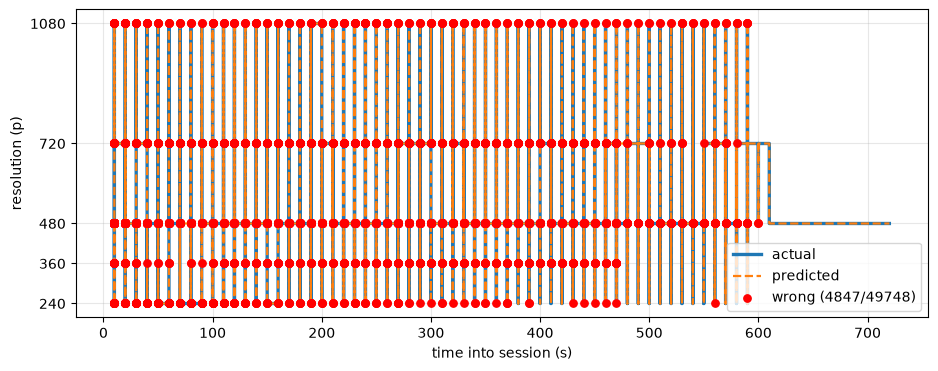

In [46]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4))
ax.step(t, true,  where="post", lw=2.4, label="actual")
ax.step(t, y_net, where="post", lw=1.6, ls="--", label="predicted")
wrong = y_net != true
ax.scatter(t[wrong], y_net[wrong], s=28, color="red", zorder=5,label=f"wrong ({wrong.sum()}/{len(t)})")
ax.set_yticks(valid_res)
ax.set_ylabel("resolution (p)"); ax.set_xlabel("time into session (s)")
ax.legend(); ax.grid(alpha=.3)
plt.show()

In [47]:
print(accuracy_score(true, y_net))

0.9025689474953767


In [48]:
print(f1_score(true, y_net, average="weighted"))

0.8990680403168847


In [49]:
print(confusion_matrix(true, y_net))

[[  986   122   538    55     0]
 [  129  3355   952    39     1]
 [  108   176 28705   492     5]
 [   24     9  1870  7324   230]
 [    0     0    12    85  4531]]


In [54]:
y_prob = clf.predict_proba(scaler.transform(g[FEATURES]))

In [55]:
print(roc_auc_score(true, y_prob, multi_class="ovr", average="weighted"))

0.9821882036296695
